In [17]:
# ==========================================
# Phase 3 - 最终分析报告：可视化仪表盘
# 输入: data/cs2_pro_2026_Active_Final.csv
# ==========================================
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# ---------------------------------------------------------
# 0. 中文字体自动检测（Windows 优先，macOS/Linux fallback）
# ---------------------------------------------------------
available_fonts = {f.name for f in fm.fontManager.ttflist}
cjk_candidates = [
    'Microsoft YaHei', 'SimHei',         # Windows
    'PingFang SC', 'Heiti SC', 'STHeiti', # macOS
    'Noto Sans CJK SC', 'WenQuanYi Micro Hei', 'WenQuanYi Zen Hei',  # Linux
    'Arial Unicode MS',                   # 兜底
]
found_fonts = [f for f in cjk_candidates if f in available_fonts]
plt.rcParams['font.sans-serif'] = found_fonts + ['sans-serif']
plt.rcParams['axes.unicode_minus'] = False
print(f"🖊 中文字体: {found_fonts[0] if found_fonts else '未检测到, 使用 fallback'}")

# ---------------------------------------------------------
# 1. 核心视觉主题配置 (Cyberpunk CS2 Style)
# ---------------------------------------------------------
def setup_cs2_theme():
    warnings.filterwarnings('ignore')
    plt.style.use('dark_background')

    cs2_palette = ["#00E5FF", "#FF4500", "#00FF00", "#FF00FF", "#FFFF00"]
    sns.set_palette(cs2_palette)
    sns.set_context("notebook", font_scale=1.1)

    theme_params = {
        'axes.facecolor': '#121212', 'figure.facecolor': '#0a0a0a',
        'grid.color': '#333333', 'grid.linestyle': '--', 'axes.edgecolor': '#555555',
        'text.color': '#E0E0E0', 'axes.labelcolor': '#E0E0E0',
        'xtick.color': '#A0A0A0', 'ytick.color': '#A0A0A0'
    }
    plt.rcParams.update(theme_params)
    print("🎨 CS2 暗黑赛博风主题已激活")

# ---------------------------------------------------------
# 2. 绘图工厂：高复用组件
# ---------------------------------------------------------
def plot_cs2_bar(ax, data, x_col, y_col=None, title="", color_palette="cool", orient='v', annotate=True):
    if orient == 'v':
        sns.barplot(data=data, x=x_col, y=y_col, palette=color_palette, ax=ax, edgecolor='#121212')
    else:
        sns.barplot(data=data, x=x_col, y=y_col, palette=color_palette, ax=ax, edgecolor='#121212', orient='h')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    sns.despine(ax=ax, left=True, bottom=True)
    if annotate and orient == 'v':
        for p in ax.patches:
            height = p.get_height()
            if not np.isnan(height) and height > 0:
                ax.annotate(f"{int(height)}", (p.get_x() + p.get_width() / 2., height),
                            ha='center', va='bottom', fontsize=12, fontweight='bold', color='white',
                            xytext=(0, 5), textcoords='offset points')

def plot_cs2_pie(ax, series_data, title="", palette_name="Set2"):
    colors = sns.color_palette(palette_name, len(series_data))
    _, _, autotexts = ax.pie(series_data, labels=series_data.index, autopct='%1.1f%%',
                             startangle=140, colors=colors,
                             wedgeprops={'edgecolor': '#121212', 'linewidth': 2})
    plt.setp(autotexts, size=11, weight="bold", color="white")
    ax.set_title(title, fontsize=16, fontweight='bold', pad=10)

def plot_cs2_hist(ax, data, title="", color="#00E5FF", bins=30, show_stats=False):
    clean_data = pd.to_numeric(pd.Series(data), errors='coerce').dropna()
    sns.histplot(clean_data, bins=bins, kde=True, color=color, edgecolor='black', ax=ax)
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    sns.despine(ax=ax, left=True, bottom=True)
    if show_stats and len(clean_data) > 0:
        mean_v = clean_data.mean()
        median_v = clean_data.median()
        ax.axvline(mean_v, color='#FFFF00', linestyle='-.', linewidth=1.8, label=f'Mean: {mean_v:.1f}')
        ax.axvline(median_v, color='#FF4500', linestyle='--', linewidth=1.8, label=f'Median: {median_v:.1f}')
        ax.legend(loc='upper right', facecolor='#121212')

# ---------------------------------------------------------
# 3. 数据加载与预热
# ---------------------------------------------------------
setup_cs2_theme()
df_pro = pd.read_csv('data/cs2_pro_2026_Active_Final.csv')
print(f"📊 报告准备就绪：已载入 {len(df_pro)} 名选手的核心指标")


🖊 中文字体: STHeiti
🎨 CS2 暗黑赛博风主题已激活
📊 报告准备就绪：已载入 198 名选手的核心指标


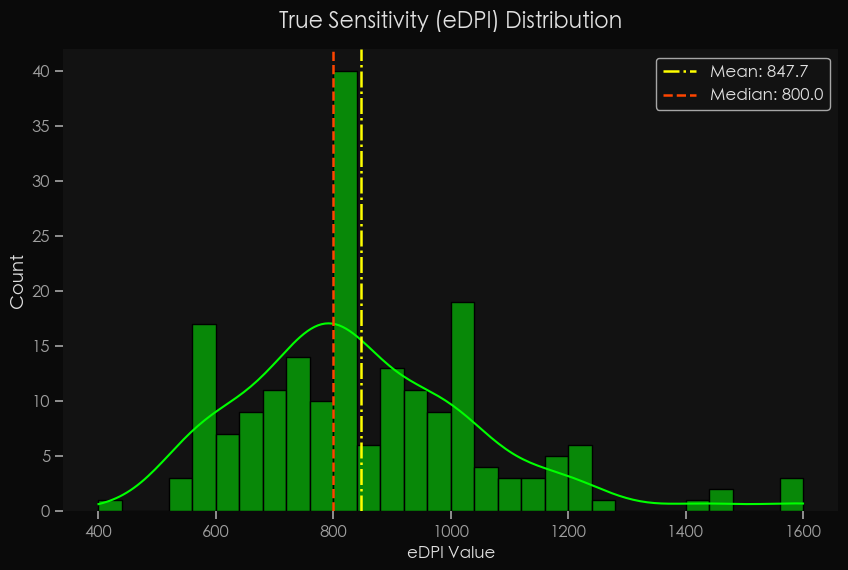

TypeError: Legend.__init__() got an unexpected keyword argument 'titlecolor'

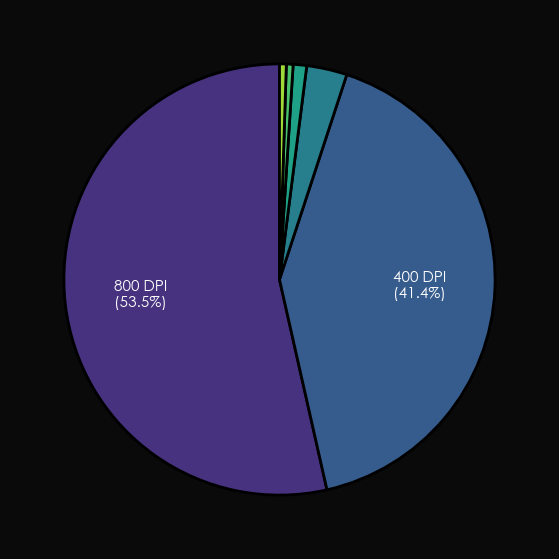

In [18]:
# --- 独立图 1：eDPI 宏观分布 ---
plt.figure(figsize=(10, 6))
plot_cs2_hist(plt.gca(), df_pro['eDPI'], title="True Sensitivity (eDPI) Distribution", color="#00FF00", show_stats=True)
plt.xlabel('eDPI Value', fontsize=12)
plt.savefig('figures/eDPI.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

# --- 独立图 2：DPI 硬件偏好 ---
plt.figure(figsize=(10, 7))
dpi_counts = df_pro['DPI'].value_counts()
colors = sns.color_palette("viridis", len(dpi_counts))
wedges, texts = plt.pie(dpi_counts, startangle=90, colors=colors,
                         wedgeprops={'edgecolor': 'black', 'linewidth': 2})
# 只标注 >= 5% 的扇区
for i, (wedge, pct) in enumerate(zip(wedges, dpi_counts.values / dpi_counts.sum() * 100)):
    if pct >= 5:
        ang = (wedge.theta2 - wedge.theta1) / 2. + wedge.theta1
        x = 0.65 * np.cos(np.deg2rad(ang))
        y = 0.65 * np.sin(np.deg2rad(ang))
        plt.annotate(f'{dpi_counts.index[i]:.0f} DPI\n({pct:.1f}%)', xy=(x, y),
                     ha='center', va='center', fontsize=11, fontweight='bold', color='white')
plt.legend(wedges, [f'{int(k)} DPI ({v}人)' for k, v in dpi_counts.items()],
           title="Hardware DPI", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1),
           facecolor='#121212', edgecolor='#555555', label_color='white', title_color='white')
plt.title('Hardware DPI Preference', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('figures/DPI.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

# --- 独立图 3：DPI vs Sens 关系散点图 ---
plt.figure(figsize=(12, 7))
ax = plt.gca()
sns.scatterplot(data=df_pro, x='DPI', y='Sensitivity', hue='DPI', palette='viridis',
                size='eDPI', sizes=(40, 300), alpha=0.8, edgecolor='w', ax=ax, legend=False)
ax.axhline(1.0, color='#FF00FF', linestyle='--', alpha=0.6, label='Sens = 1.0 (Pixel Skipping Threshold)')
ax.set_title('Sensitivity by DPI (Lower Input Lag Meta)', fontsize=18, fontweight='bold', color='#FFFF00', pad=15)
ax.set_xlabel('Hardware DPI', fontsize=12)
ax.set_ylabel('In-Game Sensitivity', fontsize=12)
ax.set_xticks(sorted(df_pro['DPI'].dropna().unique()))
ax.legend(loc='upper right', facecolor='#121212')
sns.despine(ax=ax, left=True, bottom=True)
plt.savefig('figures/Sensitivity by DPI.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()


In [ ]:
# --- 独立图 4：鼠标回报率 ---
plt.figure(figsize=(10, 6))
hz_counts = df_pro.dropna(subset=['Hz'])['Hz'].value_counts().sort_index().reset_index()
hz_counts.columns = ['Polling Rate', 'Count']
hz_counts['Polling Rate'] = hz_counts['Polling Rate'].astype(int)
plot_cs2_bar(plt.gca(), hz_counts, x_col='Polling Rate', y_col='Count', title="Mouse Polling Rate (Hz)", color_palette="cool")
plt.xlabel('Polling Rate (Hz)', fontsize=12)
plt.savefig('figures/Mouse Polling Rate.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

# --- 独立图 5：显示器刷新率 ---
plt.figure(figsize=(10, 6))
df_pro['Refresh_clean'] = df_pro['Refresh Rate'].astype(str).str.extract(r'(\d+)').astype(float)
rr_counts = df_pro.dropna(subset=['Refresh_clean'])['Refresh_clean'].value_counts().sort_index().reset_index()
rr_counts.columns = ['Monitor Hz', 'Count']
rr_counts['Monitor Hz'] = rr_counts['Monitor Hz'].astype(int)
plot_cs2_bar(plt.gca(), rr_counts, x_col='Monitor Hz', y_col='Count', title="Monitor Refresh Rate (Hz)", color_palette="cool")
plt.xlabel('Refresh Rate (Hz)', fontsize=12)
plt.savefig('figures/Monitor Hz.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

# --- 独立图 6：最高 FPS 限制 ---
plt.figure(figsize=(10, 6))
df_fps = df_pro[df_pro['Maximum FPS In Game'] != 'Unknown']
fps_counts = df_fps['Maximum FPS In Game'].value_counts().reset_index()
fps_counts.columns = ['Max FPS', 'Count']
plot_cs2_bar(plt.gca(), fps_counts, x_col='Max FPS', y_col='Count', title="Maximum FPS In Game Limit", color_palette="magma")
plt.xlabel('FPS Cap', fontsize=12)
plt.savefig('figures/Maximun FPS.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()


In [ ]:
df_crosshair = df_pro.dropna(subset=['Gap', 'Length', 'Thickness', 'Color']).copy()

# --- 独立图 7：准星几何 ---
plt.figure(figsize=(10, 7))
ax = plt.gca()
sns.scatterplot(data=df_crosshair, x='Gap', y='Length', size='Thickness', hue='Dot',
                sizes=(20, 400), alpha=0.7, palette=['#00E5FF', '#FF00FF'], ax=ax, edgecolor='w')
ax.set_title('Crosshair Geometry (Gap vs Length)', fontsize=18, fontweight='bold', color='#00FF00', pad=15)
ax.axvline(0, color='#555555', linestyle='--')
sns.despine(ax=ax, left=True, bottom=True)
plt.savefig('figures/Crosshair Geometry.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

# --- 独立图 8：基础颜色 ---
plt.figure(figsize=(10, 6))
color_counts = df_crosshair['Color'].value_counts().reset_index()
color_counts.columns = ['Color', 'Count']

base_color_map = {
    'Green': '#00FF00', 'Cyan': '#00FFFF', 'Yellow': '#FFFF00',
    'Red': '#FF0000', 'Blue': '#0055FF', 'Pink': '#FF00FF',
    'Light Blue': '#00A8FF', 'Custom': '#AAAAAA'
}
exact_palette = [base_color_map.get(c, '#888888') for c in color_counts['Color']]

plot_cs2_bar(plt.gca(), color_counts, x_col='Count', y_col='Color',
             title='Base Color Preference', color_palette=exact_palette, orient='h')
plt.ylabel('')
plt.xlabel('Player Count', fontsize=12)
plt.tight_layout()
plt.savefig('figures/Base Color.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

# --- 独立图 9：Dot & Outline ---
plt.figure(figsize=(8, 8))
df_crosshair['Toggle Config'] = 'Dot:' + df_crosshair['Dot'].astype(str) + ' | Outline:' + df_crosshair['Outline'].astype(str)
toggle_counts = df_crosshair['Toggle Config'].value_counts()
plot_cs2_pie(plt.gca(), toggle_counts, title='Visibility Toggles (Dot & Outline)', palette_name='Set2')
plt.savefig('figures/Dot and Outline.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

# --- 独立图 10：Custom RGB ---
import matplotlib.patheffects as path_effects

plt.figure(figsize=(14, 8))
custom_df = df_pro[df_pro['Color'] == 'Custom'].dropna(subset=['Red', 'Green', 'Blue']).copy()

def rgb_to_hex(r, g, b):
    return '#{:02x}{:02x}{:02x}'.format(
        int(max(0, min(r, 255))), int(max(0, min(g, 255))), int(max(0, min(b, 255)))
    ).upper()

def get_color_name(r, g, b):
    if r == 255 and g == 255 and b == 255: return 'Pure White'
    if r == 0 and g == 255 and b == 255: return 'Pure Cyan'
    if r == 255 and g == 0 and b == 255: return 'Magenta'
    if r == 0 and g == 255 and b == 0: return 'Pure Green'
    if r == 250 and g == 250 and b == 250: return 'Off-White'
    if g > 200 and r < 100 and b < 100: return 'Neon Green'
    if g > 200 and b > 120 and r < 100: return 'Mint/Cyan-Green'
    if r > 200 and g > 200 and b < 100: return 'Yellow'
    return 'Custom Mix'

custom_df['Hex_Color'] = custom_df.apply(lambda row: rgb_to_hex(row['Red'], row['Green'], row['Blue']), axis=1)
custom_df['Color_Name'] = custom_df.apply(lambda row: get_color_name(row['Red'], row['Green'], row['Blue']), axis=1)
custom_df['RGB_Label'] = 'RGB(' + custom_df['Red'].astype(int).astype(str) + ',' + custom_df['Green'].astype(int).astype(str) + ',' + custom_df['Blue'].astype(int).astype(str) + ')'

top_colors = custom_df.groupby(['RGB_Label', 'Hex_Color', 'Color_Name']).size().reset_index(name='Count').sort_values(by='Count', ascending=False).head(8).reset_index(drop=True)
top_colors['Label'] = top_colors['Color_Name'] + '\n' + top_colors['RGB_Label']

ax = plt.gca()
ax.barh(top_colors['Label'], top_colors['Count'], color=top_colors['Hex_Color'], edgecolor='#FFFFFF', linewidth=1.5)
ax.invert_yaxis()
ax.set_title('Unmasking "Custom" Color (True RGB Variants)', fontsize=18, fontweight='bold', color='#FFFF00', pad=15)
ax.set_xlabel('Player Count', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for i, row in top_colors.iterrows():
    players = custom_df[custom_df['RGB_Label'] == row['RGB_Label']]['Player'].tolist()
    player_str = ', '.join(players[:4]) + ('...' if len(players) > 4 else '')
    txt = ax.text(0.2, i, player_str, va='center', ha='left', fontsize=13, color='white', style='italic', fontweight='bold')
    txt.set_path_effects([path_effects.withStroke(linewidth=3, foreground='#000000')])

plt.tight_layout()
plt.savefig('figures/Custom Color.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()


In [ ]:
# --- 独立图 11：持枪视角 FOV ---
plt.figure(figsize=(10, 6))
df_fov = df_pro.dropna(subset=['FOV'])
fov_counts = df_fov['FOV'].value_counts().reset_index()
fov_counts.columns = ['FOV', 'Count']
plot_cs2_bar(plt.gca(), fov_counts, x_col='FOV', y_col='Count', title='Viewmodel FOV (Gun Size on Screen)', color_palette='spring')
plt.savefig('figures/FOV.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

# --- 独立图 12：Viewmodel Offsets XYZ ---
plt.figure(figsize=(10, 6))
ax = plt.gca()
offset_cols = ['Offset X', 'Offset Y', 'Offset Z']
df_offsets = df_pro[offset_cols].melt(var_name='Axis', value_name='Offset Value')
sns.boxplot(x='Axis', y='Offset Value', data=df_offsets, palette=['#00E5FF', '#00FF00', '#FF00FF'], boxprops=dict(alpha=0.6), showfliers=False, ax=ax)
sns.stripplot(x='Axis', y='Offset Value', data=df_offsets, color='white', alpha=0.5, jitter=0.2, size=5, ax=ax)
ax.axhline(0, color='#555555', linestyle='--')
ax.set_title('Viewmodel Offsets (X, Y, Z Axis)', fontsize=18, fontweight='bold', color='#FF00FF', pad=15)
sns.despine(ax=ax, left=True, bottom=True)
plt.savefig('figures/Offsets.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

# --- 独立图 13：Aspect Ratio ---
plt.figure(figsize=(8, 8))
ar_counts = df_pro['Aspect Ratio'].value_counts()
plot_cs2_pie(plt.gca(), ar_counts, title='Aspect Ratio (The 4:3 Religion)', palette_name='magma')
plt.savefig('figures/Ratio Religion.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

# --- 独立图 14：亮度偏好 ---
plt.figure(figsize=(12, 6))
if 'Brightness_num' not in df_pro.columns:
    df_pro['Brightness_num'] = pd.to_numeric(df_pro['Brightness'].astype(str).str.replace('%', ''), errors='coerce')
df_bright = df_pro.dropna(subset=['Brightness_num']).copy()
df_bright['Brightness'] = df_bright['Brightness_num'].astype(int)
bright_counts = df_bright['Brightness'].value_counts().sort_index().reset_index()
bright_counts.columns = ['Brightness', 'Count']
plot_cs2_bar(plt.gca(), bright_counts, x_col='Brightness', y_col='Count', title='Brightness Preference (%)', color_palette='Wistia')
plt.xlabel('Brightness Value', fontsize=12)
plt.tight_layout()
plt.savefig('figures/Brightness.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()


In [ ]:
# --- 独立图 15：全局阴影 ---
plt.figure(figsize=(10, 6))
shadow_counts = df_pro['Global Shadow Quality'].value_counts().reset_index()
shadow_counts.columns = ['Quality', 'Count']
plot_cs2_bar(plt.gca(), shadow_counts, x_col='Quality', y_col='Count', title="Global Shadow Quality", color_palette="autumn")
plt.xlabel('Shadow Detail Level', fontsize=12)
plt.savefig('figures/Global Shadow Quality.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

# --- 独立图 16：Shader & Particle ---
plt.figure(figsize=(10, 6))
ax = plt.gca()
df_shader_particle = df_pro[['Shader Detail', 'Particle Detail']].melt(var_name='Setting Type', value_name='Quality')
df_sp_clean = df_shader_particle[df_shader_particle['Quality'] != 'Unknown']
sns.countplot(data=df_sp_clean, x='Quality', hue='Setting Type', order=['Low', 'Medium', 'High', 'Very High'], palette=['#FF00FF', '#00E5FF'], ax=ax, edgecolor='#121212')
ax.set_title('Shader & Particle Detail', fontsize=18, fontweight='bold', color='#FFFF00', pad=15)
ax.legend(facecolor='#121212')
sns.despine(ax=ax, left=True, bottom=True)
plt.savefig('figures/Shader and Particle.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

# --- 独立图 17：MSAA ---
plt.figure(figsize=(10, 5))
df_msaa = df_pro[df_pro['Multisampling Anti-Aliasing Mode'] != 'Unknown'].copy()
msaa_counts = df_msaa['Multisampling Anti-Aliasing Mode'].value_counts().reset_index()
msaa_counts.columns = ['Mode', 'Count']
plot_cs2_bar(plt.gca(), msaa_counts, x_col='Count', y_col='Mode', title='Anti-Aliasing Mode (MSAA)', color_palette='cool', orient='h')
plt.ylabel('')
plt.savefig('figures/Anti-Aliasing.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()


In [ ]:
# --- 独立图 18：雷达缩放 ---
plt.figure(figsize=(10, 6))
plot_cs2_hist(plt.gca(), df_pro['Radar Map Zoom'].dropna(), title="Radar Map Zoom", color="#FF4500", bins=15)
plt.xlabel('Zoom Level (Smaller = View More Map)', fontsize=12)
plt.ylabel('Player Count', fontsize=12)
plt.tight_layout()
plt.savefig('figures/Map Zoom.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

# --- 独立图 19：雷达居中 ---
plt.figure(figsize=(8, 8))
center_counts = df_pro['Radar Centers The Player'].value_counts()
plot_cs2_pie(plt.gca(), center_counts, title="Radar Centers The Player?", palette_name="Set2")
plt.savefig('figures/Radar Center.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

# --- 独立图 20：雷达旋转 ---
plt.figure(figsize=(8, 8))
rotate_counts = df_pro['Radar is Rotating'].value_counts()
plot_cs2_pie(plt.gca(), rotate_counts, title="Radar is Rotating?", palette_name="cool")
plt.savefig('figures/Radar Rotate.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()


In [ ]:
# --- 独立图 21：纹理过滤 ---
plt.figure(figsize=(12, 5))
df_texture = df_pro[df_pro['Texture Filtering Mode'] != 'Unknown'].copy()
texture_counts = df_texture['Texture Filtering Mode'].value_counts().reset_index()
texture_counts.columns = ['Mode', 'Count']
plot_cs2_bar(plt.gca(), texture_counts, x_col='Count', y_col='Mode', title='Texture Filtering Mode', color_palette='Wistia', orient='h')
plt.ylabel('')
plt.xlabel('Player Count', fontsize=12)
plt.tight_layout()
plt.savefig('figures/Texture Filtering Mode.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()


In [ ]:
# --- 独立图 22：分辨率 Top 10 ---
plt.figure(figsize=(12, 7))
res_counts = df_pro['Resolution'].value_counts().head(10).reset_index()
res_counts.columns = ['Resolution', 'Count']

ax = plt.gca()
sns.barplot(data=res_counts, x='Count', y='Resolution', palette='cool', ax=ax, edgecolor='#121212', linewidth=1.5)
ax.set_title('Top 10 Resolution Preferences', fontsize=18, fontweight='bold', color='#00E5FF', pad=15)
ax.set_xlabel('Player Count', fontsize=12)
ax.set_ylabel('')
sns.despine(ax=ax, left=True, bottom=True)

for p in ax.patches:
    width = p.get_width()
    if not np.isnan(width) and width > 0:
        ax.text(width + 0.8, p.get_y() + p.get_height() / 2., f'{int(width)}',
                ha='left', va='center', fontsize=12, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('figures/resolution.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()
